In [1]:
import pandas as pd
import numpy as np
import os
import tiktoken
import math
import numpy as np
import time
import datetime
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt

torch.set_float32_matmul_precision('high')
torch.manual_seed(137)
torch.cuda.manual_seed_all(137)

In [ ]:
vocab_size = 50304
block_cnt = 12
seq_len = 32
batch_size = 8
total_batch_size = 256
num_head = 12
embedding_size = 768
max_learning_rate = 1e-4
max_steps = 100000
max_steps = 100

data_dir = "FNSPID_transformed"
device = "cuda"
printing_freq = 1000 # Print results every X steps
printing_freq = 10 # Print results every X steps
saving_model_freq = 10000 # Saves torch model every X steps


In [6]:
class AttentionModule(nn.Module):

    def __init__(self, num_head, embedding_size):
        super().__init__()
        self.num_head = num_head
        self.embedding_size = embedding_size
        assert self.embedding_size % self.num_head == 0
        self.qkv_matrices = nn.Linear(self.embedding_size,
                                      3 * self.embedding_size)
        self.qkv_projections = nn.Linear(self.embedding_size,
                                         self.embedding_size)

    def forward(self, x):
        batch_size, seq_len, q_dim = x.size()
        qkv = self.qkv_matrices(x)
        q, k, v = qkv.split(self.embedding_size, dim=2)
        k = k.view(batch_size, seq_len,
                   self.num_head, q_dim // self.num_head).transpose(1, 2)
        q = q.view(batch_size, seq_len,
                   self.num_head, q_dim // self.num_head).transpose(1, 2)
        v = v.view(batch_size, seq_len,
                   self.num_head, q_dim // self.num_head).transpose(1, 2)
        attn = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        attn = attn.transpose(1, 2).contiguous()
        attn = attn.view(batch_size, seq_len, q_dim)
        return self.qkv_projections(attn)


In [ ]:
class MultiLayerPerceptron(nn.Module):

    def __init__(self, embedding_size):
        super().__init__()
        self.linear1 = nn.Linear(embedding_size, 4 * embedding_size)
        self.activation = nn.GELU(approximate='tanh')
        self.linear2 = nn.Linear(4 * embedding_size, embedding_size)

    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        x = self.linear2(x)
        return x

In [ ]:
class TransformerBlock(nn.Module):

    def __init__(self, num_head, embedding_size):
        super().__init__()
        self.layer_norm1 = nn.LayerNorm(embedding_size)
        self.multi_head_attention = AttentionModule(
                                        num_head=num_head,
                                        embedding_size=embedding_size
                                        )
        self.layer_norm2 = nn.LayerNorm(embedding_size)
        self.multi_layer_perceptron = MultiLayerPerceptron(
                                        embedding_size=embedding_size
                                        )

    def forward(self, x):
        x = x + self.multi_head_attention(self.layer_norm1(x))
        x = x + self.multi_layer_perceptron(self.layer_norm2(x))
        return x

In [ ]:
class Transformer(nn.Module):

    def __init__(self, seq_len, vocab_size, block_cnt, num_head,
                 embedding_size):
        super().__init__()
        self.seq_len = seq_len
        self.vocab_size = vocab_size
        self.block_cnt = block_cnt
        self.num_head = num_head
        self.embedding_size = embedding_size

        self.positional_embeddings = nn.Embedding(self.seq_len,
                                                  self.embedding_size)
        self.word_embeddings = nn.Embedding(self.vocab_size,
                                            self.embedding_size)
        self.blocks = nn.Sequential(*[TransformerBlock(num_head=num_head,
                embedding_size=embedding_size) for _ in range(self.block_cnt)])
        self.layer_norm = nn.LayerNorm(self.embedding_size)
        self.unembed = nn.Linear(self.embedding_size,
                                 self.vocab_size, bias=False)
        self.word_embeddings.weight = self.unembed.weight

        self.apply(self.initialize_weights)

    def initialize_weights(self, module):
        if isinstance(module, nn.Linear):
            std = 0.0144 / self.block_cnt ** 0.5
            torch.nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, token_ids, labels=None):
        batch_size, seq_len = token_ids.size()
        position_idxs = torch.arange(0, seq_len, dtype=torch.long,
                                     device=token_ids.device)
        p = self.positional_embeddings(position_idxs)
        x = self.word_embeddings(token_ids) + p
        x = self.blocks(x)
        x = self.layer_norm(x)
        logits = self.unembed(x)
        loss = None
        if labels is not None:
            input = logits.view(-1, logits.size(-1))
            target = labels.view(-1)
            loss = F.cross_entropy(input, target)
        return logits, loss



In [ ]:
class DataLoader:
    def __init__(self, batch_size, seq_len, split):
        self.batch_size = batch_size
        self.seq_len = seq_len
        self.split = split
        splits = ['train', 'validation', 'test']
        assert split in splits, f"invalid split: {split}"
        files = os.listdir(data_dir)
        files = [filename for filename in files if ((split in filename) \
                                      and filename.endswith(".npy"))]
        files = [os.path.join(data_dir, s) for s in files]
        self.shards = files
        self.shard_cnt = len(self.shards)
        assert len(files) >= 1, f"found {len(files)} files for split {split}"
        self.current_shard = 0
        self.choose_shard_and_position()

    def load_tokens(self, filename):
        # Long array of integers
        idxs_array = np.load(filename)
        idxs_array = idxs_array.astype(np.int32)
        # Long tensor of integers
        idxs_tensor = torch.tensor(idxs_array, dtype=torch.long)
        return idxs_tensor

    def next_batch(self):
        batch_size, seq_len = self.batch_size, self.seq_len
        start = self.current_position
        end = self.current_position+batch_size*seq_len+1
        buf = self.tokens[start:end]
        x = (buf[:-1]).view(batch_size, seq_len)
        y = (buf[1:]).view(batch_size, seq_len)
        self.current_position += batch_size * seq_len 
        if self.current_position + \
         (batch_size * seq_len + 1) > len(self.tokens):
            # The current shard is exhausted, so we need to load the next one
            self.choose_shard_and_position()
        return x, y

    def choose_shard_and_position(self):
        if self.split == "train":
            # For training, we want to move from one shard to the other, and
            # randomize the position
            self.current_shard = (self.current_shard + 1) % self.shard_cnt
            self.current_position = np.random.randint(0, self.batch_size - 1)
        else:
            # For validation and testing, we always want to start from the
            # beginning of the first shard
            self.current_shard = 0
            self.current_position = 0
        self.tokens = self.load_tokens(self.shards[self.current_shard])



In [ ]:

train_loader = DataLoader(batch_size=batch_size, seq_len=seq_len,
                          split="train")
validation_loader = DataLoader(batch_size=batch_size, seq_len=seq_len,
                               split="validation")

model = Transformer(seq_len=seq_len, vocab_size=vocab_size,
                    block_cnt=block_cnt, num_head=num_head,
                    embedding_size=embedding_size)
model.to(device)

tokenizer = tiktoken.get_encoding("gpt2")

params = {param for _, param in model.named_parameters() if param.requires_grad}
optimizer = torch.optim.Adam(params, lr=max_learning_rate, betas=(0.9, 0.99))

# Prefix for saving artifacts
now = datetime.datetime.now()
now_str = now.strftime("%Y-%m-%d_%H-%M-%S")

# Create a log
log_dir = "log"
os.makedirs(log_dir, exist_ok=True)
log_file = os.path.join(log_dir, f"log.txt")
with open(log_file, "w") as f:
    pass # clears contents

training_loss = [] # (step, train_loss)
validation_loss = [] # (step, valid_loss)
assert total_batch_size % (batch_size * seq_len) == 0
grad_cumul_steps = total_batch_size // (batch_size * seq_len)

for step in range(max_steps):
    last_step = (step == max_steps - 1)

    # Generate with the model 
    if step % printing_freq == 0 or last_step:
        model.eval()
        num_return_sequences = 4
        max_length = 32
        tokens = tokenizer.encode("Hello, I'm a language model,")
        tokens = torch.tensor(tokens, dtype=torch.long)
        tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1)
        xgen = tokens.to(device)
        sample_rng = torch.Generator(device=device)
        sample_rng.manual_seed(42)
        while xgen.size(1) < max_length:
            # forward the model to get the logits
            with torch.no_grad():
                with torch.autocast(device_type=device, dtype=torch.bfloat16):
                    logits, loss = model(xgen) # (B, T, vocab_size)
                # take the logits at the last position
                logits = logits[:, -1, :] # (B, vocab_size)
                # get the probabilities
                probs = F.softmax(logits, dim=-1)
                # do top-k sampling of 50 (huggingface pipeline default)
                # topk_probs here becomes (5, 50), topk_indices is (5, 50)
                topk_probs, topk_indices = torch.topk(probs, 50, dim=-1)
                # select a token from the top-k probabilities
                # note: multinomial does not demand the input to sum to 1
                ix = torch.multinomial(topk_probs, 1, generator=sample_rng) # (B, 1)
                # gather the corresponding indices
                xcol = torch.gather(topk_indices, -1, ix) # (B, 1)
                # append to the sequence
                xgen = torch.cat((xgen, xcol), dim=1)
        # print the generated text
        for i in range(num_return_sequences):
            tokens = xgen[i, :max_length].tolist()
            decoded = tokenizer.decode(tokens)
            print(f"sample {i}: {decoded}")


    # Evaluate in validation dataset every printing_freq steps
    if step % printing_freq == 0 or last_step:
        model.eval()
        validation_loader.choose_shard_and_position()
        with torch.no_grad():
            validation_loss_cumul = 0.0
            val_loss_steps = 20
            for _ in range(val_loss_steps):
                x, y = validation_loader.next_batch()
                x, y = x.to(device), y.to(device)
                with torch.autocast(device_type=device, dtype=torch.bfloat16):
                    logits, loss = model(x, y)
                loss = loss / val_loss_steps
                validation_loss_cumul += loss.detach()
        validation_update_msg = f"Validation loss before step {step} " + \
        f"is {validation_loss_cumul.item():.6f}"
        print(validation_update_msg)
        validation_loss.append((step, validation_loss_cumul.item()))
        with open(log_file, "a") as f:
            f.write(validation_update_msg)

    # Save the model every saving_model_freq steps
    if (step % saving_model_freq == 0 or last_step) and step > 0:
        model_path = os.path.join(log_dir, f"{now_str}_model_{step:05d}.pth")
        torch.save(model, model_path)

    # Forward and backward passes
    model.train()
    optimizer.zero_grad()
    train_loss_cumul = 0.0
    for _ in range(grad_cumul_steps):
        x, y = train_loader.next_batch()
        x, y = x.to(device), y.to(device)
        with torch.autocast(device_type=device, dtype=torch.bfloat16):
            logits, loss = model(x, y)
        loss = loss / grad_cumul_steps
        train_loss_cumul += loss.detach()
        loss.backward()
    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    lr = max_learning_rate
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    optimizer.step()
    tokens_processed = train_loader.batch_size * \
    train_loader.seq_len * grad_cumul_steps
    # Output training results every printing_freq steps
    if step % printing_freq == 0 or last_step:
      loss_val = train_loss_cumul.item()
      msg = f"Training loss before step {step+1} is {loss_val:.6f}"
      training_loss.append((step+1, loss_val))
      with open(log_file, "a") as f:
          f.write(msg)

# Save the lists of training loss and valid
np.save(os.path.join(log_dir, f'{now_str}_training_loss.npy'),
        np.array(training_loss))
np.save(os.path.join(log_dir, f'{now_str}_validation_loss.npy'),
        np.array(validation_loss))

# TODO explain why accuracy doesn't really matter

Validation loss before step 0 is {validation_loss_cumul.item():.6f}
Validation loss before step 100 is {validation_loss_cumul.item():.6f}
Validation loss before step 200 is {validation_loss_cumul.item():.6f}
Validation loss before step 300 is {validation_loss_cumul.item():.6f}
Validation loss before step 400 is {validation_loss_cumul.item():.6f}
Validation loss before step 500 is {validation_loss_cumul.item():.6f}
Validation loss before step 600 is {validation_loss_cumul.item():.6f}
Validation loss before step 700 is {validation_loss_cumul.item():.6f}
Validation loss before step 800 is {validation_loss_cumul.item():.6f}
Validation loss before step 900 is {validation_loss_cumul.item():.6f}
Validation loss before step 999 is {validation_loss_cumul.item():.6f}


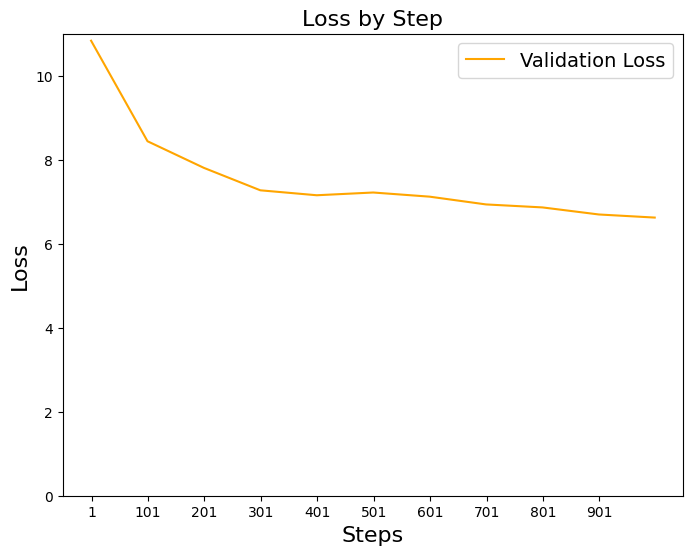

In [28]:
# Plot train and validation performance
tick_width = 100
train_steps, train_losses = zip(*training_loss)
val_steps, val_losses = zip(*validation_loss)
custom_ticks = range(min(train_steps), max(train_steps) + 1, tick_width)
plt.figure(figsize=(8, 6))
# plt.plot(train_steps, train_losses, label='Train Loss', color='blue')
plt.plot(val_steps, val_losses, label='Validation Loss', color='orange')
plt.xticks(custom_ticks)
plt.xlabel('Steps', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.ylim(0, 11)
plt.title('Loss by Step', fontsize=16)
plt.legend(fontsize=14)
plt.show()